<a href="https://colab.research.google.com/github/subhanreddy2007-star/FMML-Projects-and-Labs/blob/main/pca_m2_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Sample Dataset for PCA Demonstration

In [8]:
import numpy as np
import pandas as pd

np.random.seed(42)
X_sample = np.random.rand(100, 5)

X_sample[:, 1] = X_sample[:, 0] * 0.8 + np.random.rand(100) * 0.2
X_sample[:, 2] = X_sample[:, 0] * 0.5 + X_sample[:, 1] * 0.3 + np.random.rand(100) * 0.1

sample_df = pd.DataFrame(X_sample, columns=[f'feature_{i+1}' for i in range(X_sample.shape[1])])

print("Sample Dataset created with shape:", sample_df.shape)
display(sample_df.head())

Sample Dataset created with shape: (100, 5)


,feature_1,feature_2,feature_3,feature_4,feature_5
0,0.374540,0.439264,0.335943,0.598658,0.156019
1,0.155995,0.232015,0.175461,0.601115,0.708073
2,0.020584,0.078373,0.051505,0.212339,0.181825
3,0.183405,0.309483,0.193417,0.431945,0.291229
4,0.611853,0.626429,0.505919,0.366362,0.456070


### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a set of correlated variables into a smaller set of uncorrelated variables called principal components. The first principal component accounts for the largest possible variance in the data, and each succeeding component accounts for the highest possible variance under the constraint that it is orthogonal to the preceding components. This helps in identifying the most significant underlying patterns in the data.

In [9]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

np.random.seed(42)
X_sample = np.random.rand(100, 5)

X_sample[:, 1] = X_sample[:, 0] * 0.8 + np.random.rand(100) * 0.2
X_sample[:, 2] = X_sample[:, 0] * 0.5 + X_sample[:, 1] * 0.3 + np.random.rand(100) * 0.1

sample_df = pd.DataFrame(X_sample, columns=[f'feature_{i+1}' for i in range(X_sample.shape[1])])

print("Sample Dataset created with shape:", sample_df.shape)
display(sample_df.head())

pca = PCA(n_components=3)

X_pca = pca.fit_transform(sample_df)

pca_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2', 'principal_component_3'])

print("Shape of PCA transformed data:", pca_df.shape)
display(pca_df.head())

Sample Dataset created with shape: (100, 5)


,feature_1,feature_2,feature_3,feature_4,feature_5
0,0.374540,0.439264,0.335943,0.598658,0.156019
1,0.155995,0.232015,0.175461,0.601115,0.708073
2,0.020584,0.078373,0.051505,0.212339,0.181825
3,0.183405,0.309483,0.193417,0.431945,0.291229
4,0.611853,0.626429,0.505919,0.366362,0.456070


Shape of PCA transformed data: (100, 3)


,principal_component_1,principal_component_2,principal_component_3
0,-0.154302,-0.180244,0.268004
1,-0.524313,0.259966,-0.031837
2,-0.770531,-0.388773,0.022197
3,-0.449423,-0.172389,0.089128
4,0.146134,-0.098395,-0.140772


In [10]:
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio by each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

cumulative_variance = explained_variance_ratio.cumsum()
print(f"\nCumulative explained variance: {cumulative_variance[-1]:.4f}")

Explained variance ratio by each principal component:
Principal Component 1: 0.5177
Principal Component 2: 0.2976
Principal Component 3: 0.1779

Cumulative explained variance: 0.9932


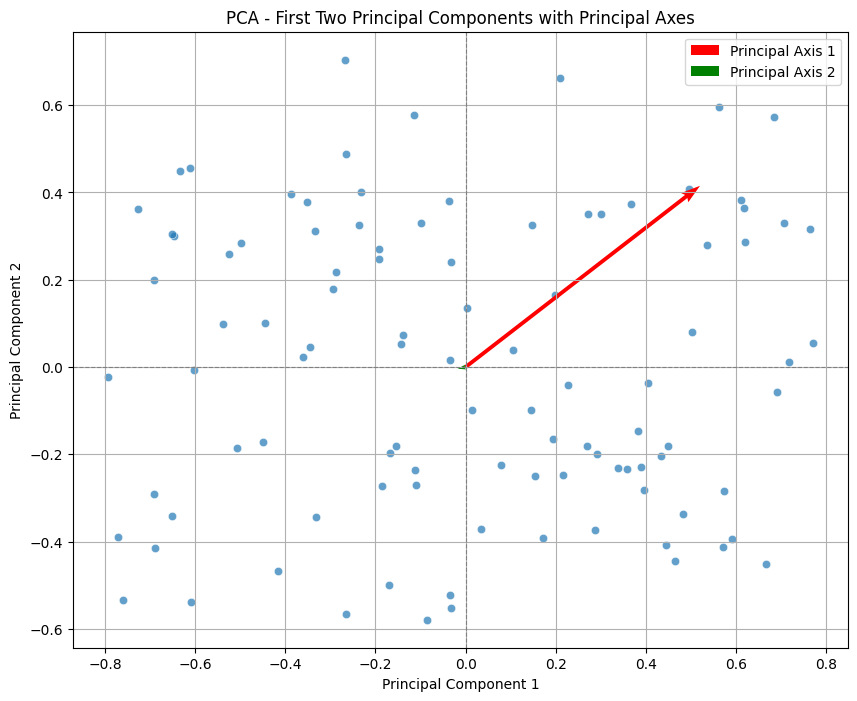

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=pca_df, alpha=0.7)
plt.title('PCA - First Two Principal Components with Principal Axes')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

components = pca.components_

scale_factor = pca_df.iloc[:, :2].values.std() * 2

plt.quiver(0, 0, components[0, 0] * scale_factor, components[0, 1] * scale_factor,
           angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Principal Axis 1')
plt.quiver(0, 0, components[1, 0] * scale_factor, components[1, 1] * scale_factor,
           angles='xy', scale_units='xy', scale=1, color='green', width=0.005, label='Principal Axis 2')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.legend()
plt.show()

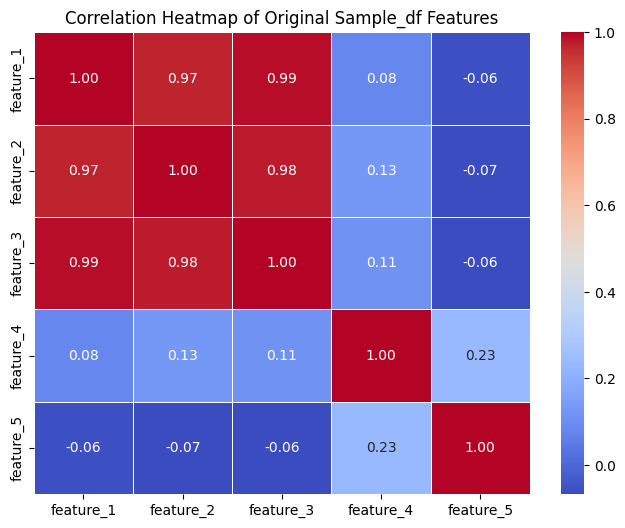

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = sample_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Original Sample_df Features')
plt.show()

pca is used in the processing of the photo and vedio  ,by using pca they are compressed to save the memory and large files can be easly be transfered  